<a href="https://colab.research.google.com/github/enzomason80-gif/python-data-science-epf-2026/blob/main/MSBSI2IN09_Python_TP_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MSBSI2IN09 - Python pour la Data Science - TP Noté

Le dossier project contenu dans le dossier python-data-science-epf-2026 contient quatre datasets en format .csv : `employees.csv`, `employment.csv`, `performance.csv` et `compensation.csv`. Ils sont contenus dans un dossier `Datasets`.

Ce TP noté évaluera ce que nous avons vu en cours sur les différentes bibliothèques de programmetion Python au programme : NumPy, Pandas, Matplotlib et Seaborn.

**Pour chaque question et sauf précision contraire, il vous sera demander d'expliquer comment et pourquoi vous avez procédé pour votre code.**

## Partie 0 - Chargement et exploration des données

### Question 1.

Chargez les datasets et affichez-en les premières lignes : qu'est-ce que ces datasets représentent ?

In [3]:
import pandas as pd

# Chargement
employees = pd.read_csv('employees.csv')
employment = pd.read_csv('employment.csv')
performance = pd.read_csv('performance.csv')
compensation = pd.read_csv('compensation.csv')

# Affichage des premières lignes
print(employees.head())
print(employment.head())
print(performance.head())
print(compensation.head())

   EmpID  Age  Gender  Education              Department  \
0  RM297   18    Male          3  Research & Development   
1  RM302   18  Female          3                   Sales   
2  RM458   18    Male          3                   Sales   
3  RM728   18    Male          2  Research & Development   
4  RM829   18    Male          1  Research & Development   

                 JobRole MaritalStatus  
0  Laboratory Technician        Single  
1   Sales Representative        Single  
2   Sales Representative        Single  
3     Research Scientist        Single  
4  Laboratory Technician        Single  
   EmpID  YearsAtCompany  YearsInCurrentRole  YearsSinceLastPromotion  \
0  RM297               0                   0                        0   
1  RM302               0                   0                        0   
2  RM458               0                   0                        0   
3  RM728               0                   0                        0   
4  RM829               0    

J'ai utilisé la bibliothèque Pandas, qui est l'outil de référence en Python pour la manipulation de données tabulaires.
La fonction pd.read_csv() permet d'importer les données structurées dans des objets appelés DataFrames. L'utilisation de .head() est essentielle lors de la phase d'exploration initiale pour valider que le chargement s'est bien déroulé et pour comprendre la structure des colonnes, elle permet d'afficher par défaut les 5 premières lignes.

## Partie 1 - NumPy

### Question 2 - Arrays NumPy.

Créer un array NumPy contenant les salaires des employés : quelle est l'utilité d'un array NumPy par rapport à un tableau ?

In [2]:
import numpy as np
salaires = np.array(compensation['MonthlyIncome'])

print("Aperçu de l'array des salaires :")
print(salaires[:10])

Aperçu de l'array des salaires :
[1420 1200 1878 1051 1904 1611 1569 1514 1675 1483]


J'ai utilisé la bibliothèque NumPy pour transformer la colonne MonthlyIncome du DataFrame compensation en un objet ndarray (tableau NumPy).

L'utilisation d'un array NumPy présente trois avantages majeurs en Data Science par rapport aux listes classiques de Python :

- Performance et rapidité (Vectorisation) : Contrairement aux listes Python, NumPy permet d'effectuer des opérations mathématiques sur l'ensemble des données d'un coup sans utiliser de boucles for. Cela rend les calculs beaucoup plus rapides, surtout sur de gros volumes de données.

- Efficacité mémoire : Cela consomme beaucoup moins d'espace qu'une liste Python qui doit stocker des pointeurs vers des objets de types potentiellement différents.

- Fonctions statistiques intégrées : NumPy offre une vaste bibliothèque de fonctions optimisées pour le calcul scientifique (moyenne, médiane, écart-type, etc.) qui s'appliquent directement sur l'array avec une syntaxe très simple.

### Question 3 - Manipulation des arrays NumPy.

Affichez les salaires moyen, maximum, minimum et median des employés.


Créez un array contenant seulement les salaires supérieurs à la moyenne, et trouvez combien d'employés ont un salaire supérieur au salaire moyen.

In [4]:
import numpy as np

salaire_moyen = np.mean(salaires)
salaire_max = np.max(salaires)
salaire_min = np.min(salaires)
salaire_median = np.median(salaires)

print(f"Salaire Moyen : {salaire_moyen:.2f}")
print(f"Salaire Maximum : {salaire_max}")
print(f"Salaire Minimum : {salaire_min}")
print(f"Salaire Médian : {salaire_median}")

salaires_sup_moyenne = salaires[salaires > salaire_moyen]

nb_employes_sup = len(salaires_sup_moyenne)

print(f"\nNombre d'employés gagnant plus que la moyenne : {nb_employes_sup}")

Salaire Moyen : 6504.99
Salaire Maximum : 19999
Salaire Minimum : 1009
Salaire Médian : 4933.0

Nombre d'employés gagnant plus que la moyenne : 497


J'ai utilisé les fonctions statistiques natives de NumPy (mean, max, min, median).

Pour sélectionner les salaires supérieurs à la moyenne, j'ai utilisé : salaires > salaire_moyen.

## Partie 2 - Pandas

### Question 4 - Description d'un DataFrame

Décrivez le dataframe correspondant au fichier `employees.csv` : dimensions, colonnes, types d'objets, ...

Combien y a-t-il d'employés dans l'entreprise ?

In [6]:
print("Informations structurelles")
employees.info()

print("\nDimensions (Lignes, Colonnes)")
print(employees.shape)

print("\nNombre total d'employés")

nb_employes = employees['EmpID'].nunique()
print(f"Il y a {nb_employes} employés dans l'entreprise.")

Informations structurelles
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   EmpID          1480 non-null   object
 1   Age            1480 non-null   int64 
 2   Gender         1480 non-null   object
 3   Education      1480 non-null   int64 
 4   Department     1480 non-null   object
 5   JobRole        1480 non-null   object
 6   MaritalStatus  1480 non-null   object
dtypes: int64(2), object(5)
memory usage: 81.1+ KB

Dimensions (Lignes, Colonnes)
(1480, 7)

Nombre total d'employés
Il y a 1470 employés dans l'entreprise.


On peut voir que c'est un dataframe de classe pandas.
IL a 1480 lignes et 7 colonnes.
Il y a au total 1470 employés dans l'entreprise.

J'ai utilisé la méthode .info() de Pandas.
Elle permet de donner:

Dimensions : Elle indique le nombre total de lignes et de colonnes.

Colonnes : Elle liste les noms de toutes les variables (Age, Gender, Department, etc.).

Types d'objets (dtypes) : Elle permet de voir si les données sont stockées comme des entiers (int64) pour l'âge ou des chaînes de caractères (object) pour le département.

Valeurs manquantes : Elle montre s'il y a des colonnes vides (non-null), ce qui est vital avant de commencer toute analyse statistique.

J'ai également utilisé l'attribut .shape qui renvoie un tuple (lignes, colonnes) pour une lecture rapide des dimensions.

### Question 5 - Manipulation d'un DataFrame

Affichez les 20 premiers employés ayant plus de 50 ans.

Affichez les 20 employés d'un département spécifique (au choix).

Ajoutez au dataframe une colonne `AgeGroup` qui vaut :

- `Junior` si l'employé a moins de 30 ans
- `Senior` sinon

Puis affichez à nouveau le début du dataframe.

In [9]:
plus_de_50 = employees[employees['Age'] > 50].head(20)
print("20 premiers employés de plus de 50 ans")
display(plus_de_50)

dept_sales = employees[employees['Department'] == 'Sales'].head(20)
print("\n20 employés du département Sales")
display(dept_sales)

employees['AgeGroup'] = employees['Age'].apply(lambda x: 'Junior' if x < 30 else 'Senior')

print("\nDataFrame avec la colonne AgeGroup")
display(employees.head())

20 premiers employés de plus de 50 ans


,EmpID,Age,Gender,Education,Department,JobRole,MaritalStatus,AgeGroup
1337,RM088,51,Male,4,Research & Development,Laboratory Technician,Married,Senior
1338,RM092,51,Male,4,Sales,Sales Executive,Single,Senior
1339,RM111,51,Female,4,Research & Development,Healthcare Representative,Single,Senior
1340,RM124,51,Male,3,Research & Development,Research Director,Single,Senior
1341,RM137,51,Male,4,Research & Development,Manufacturing Director,Single,Senior
1342,RM157,51,Male,4,Research & Development,Manufacturing Director,Married,Senior
1343,RM190,51,Female,3,Research & Development,Healthcare Representative,Single,Senior
1344,RM214,51,Male,4,Research & Development,Research Director,Married,Senior
1345,RM259,51,Male,3,Research & Development,Research Scientist,Married,Senior
1346,RM300,51,Male,3,Research & Development,Manufacturing Director,Divorced,Senior



20 employés du département Sales


,EmpID,Age,Gender,Education,Department,JobRole,MaritalStatus,AgeGroup
1,RM302,18,Female,3,Sales,Sales Representative,Single,Junior
2,RM458,18,Male,3,Sales,Sales Representative,Single,Junior
6,RM1154,18,Female,2,Sales,Sales Representative,Single,Junior
8,RM128,19,Male,1,Sales,Sales Representative,Single,Junior
10,RM172,19,Female,1,Sales,Sales Representative,Single,Junior
13,RM689,19,Male,3,Sales,Sales Representative,Single,Junior
20,RM663,20,Female,3,Sales,Sales Representative,Single,Junior
23,RM777,20,Female,3,Sales,Sales Representative,Single,Junior
25,RM877,20,Male,3,Sales,Sales Representative,Single,Junior
26,RM1179,20,Female,3,Sales,Sales Representative,Single,Junior



DataFrame avec la colonne AgeGroup


,EmpID,Age,Gender,Education,Department,JobRole,MaritalStatus,AgeGroup
0,RM297,18,Male,3,Research & Development,Laboratory Technician,Single,Junior
1,RM302,18,Female,3,Sales,Sales Representative,Single,Junior
2,RM458,18,Male,3,Sales,Sales Representative,Single,Junior
3,RM728,18,Male,2,Research & Development,Research Scientist,Single,Junior
4,RM829,18,Male,1,Research & Development,Laboratory Technician,Single,Junior


J'ai utilisé des masques booléens (ex: df['Age'] > 50) car c'est la méthode la plus rapide sous Pandas pour sélectionner des lignes selon une condition. J'ai ajouté .head(20) pour limiter l'affichage aux 20 premiers résultats comme demandé.

J'ai utilisé la fonction .apply() avec une lambda. C'est beaucoup plus efficace qu'une boucle for car cela permet d'appliquer la logique "Junior/Senior" sur toute la colonne en une seule opération.

L'affichage avec .head() permet de confirmer que la nouvelle colonne a bien été créée avec les bonnes étiquettes selon l'âge.

### Question 6 - Comparaison des départements.

Pour chaque département de l'entreprise, calculez et affichez :

- le nombre d'employés,
- l'âge moyen des employés.

Quel département est le plus proche de la parité femme / homme au niveau de ses employés ?

In [12]:
stats_dept = employees.groupby('Department').agg({'Age': 'mean', 'EmpID': 'count'})
print(stats_dept)

parite = employees.groupby(['Department', 'Gender']).size().unstack()
print("\nTableau de parité :")
print(parite)

                              Age  EmpID
Department                              
Human Resources         37.809524     63
Research & Development  37.015512    967
Sales                   36.582222    450

Tableau de parité :
Gender                  Female  Male
Department                          
Human Resources             20    43
Research & Development     380   587
Sales                      191   259


J'ai utilisé .groupby() car c'est l'outil le plus simple pour agréger des données par catégorie. J'ai combiné .agg() pour obtenir l'âge moyen et l'effectif en une seule étape. Pour la parité, j'ai compté les genres par département puis utilisé .unstack() pour rendre le tableau lisible et comparer facilement le nombre d'hommes et de femmes.

Le departement le plus proche de la parité est donc le departement Sales.

## Partie 3 - Matplotlib

### Question 7 - Histogramme.

Créez un histogramme montrant la distribution des âges des employés.

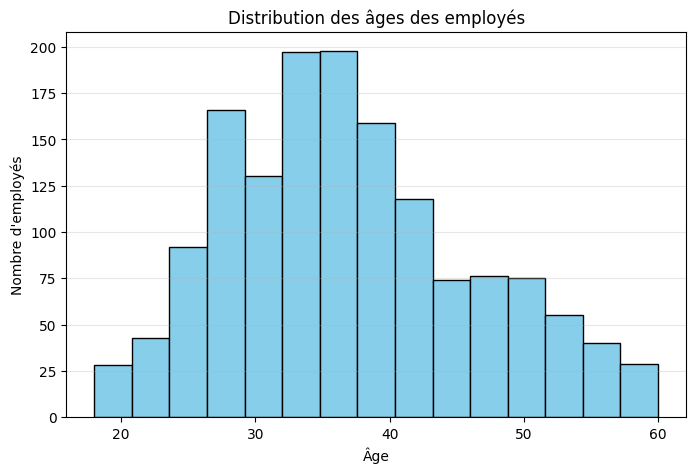

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(employees['Age'], bins=15, color='skyblue', edgecolor='black')
plt.title("Distribution des âges des employés")
plt.xlabel("Âge")
plt.ylabel("Nombre d'employés")
plt.grid(axis='y', alpha=0.3)
plt.show()

L'histogramme est le graphique idéal pour visualiser la distribution d'une variable continue comme l'âge. J'ai réglé les bins colonnes à 15 pour voir précisément les tranches d'âge les plus représentées.

### Question 8 - Choix du graphe.

Choisissez un type de graphe approprié pour représenter le nombre d'employés par département, créez le puis affichez le.

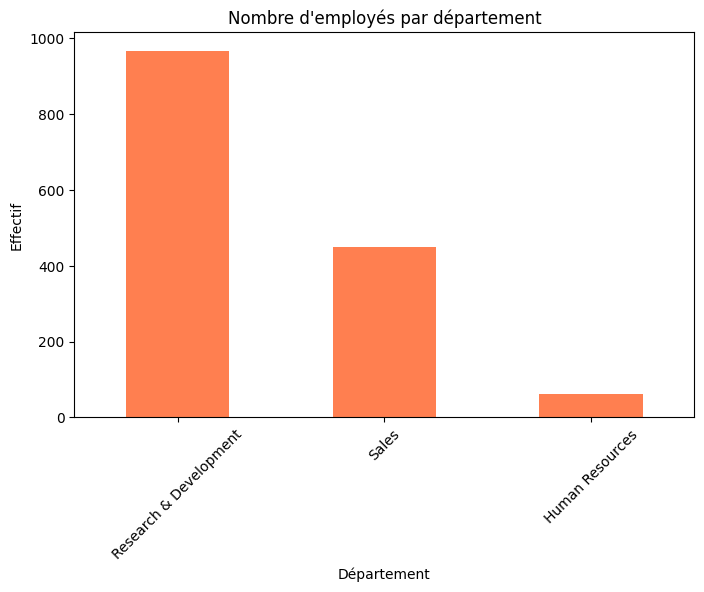

In [14]:
dept_counts = employees['Department'].value_counts()

plt.figure(figsize=(8, 5))
dept_counts.plot(kind='bar', color='coral')
plt.title("Nombre d'employés par département")
plt.xlabel("Département")
plt.ylabel("Effectif")
plt.xticks(rotation=45)
plt.show()

Pour comparer les departements, le diagramme en barres est le plus visible. J'ai utilisé value_counts() pour obtenir les totaux par département et la méthode .plot(kind='bar') de Pandas, qui s'appuie sur Matplotlib pour générer le graphique.

## Partie 4 - Seaborn

### Question 9 - Graphes avec Seaborn.

Prenez les deux graphes que vous venez d'afficher avec Matplotlib et refaites les avec Seaborn pour qu'ils apparaissent en tant que deux sous-graphes au sein d'une même figure.

/tmp/ipykernel_2851/878741393.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=employees, x='Department', ax=axes[1], palette='Set2')


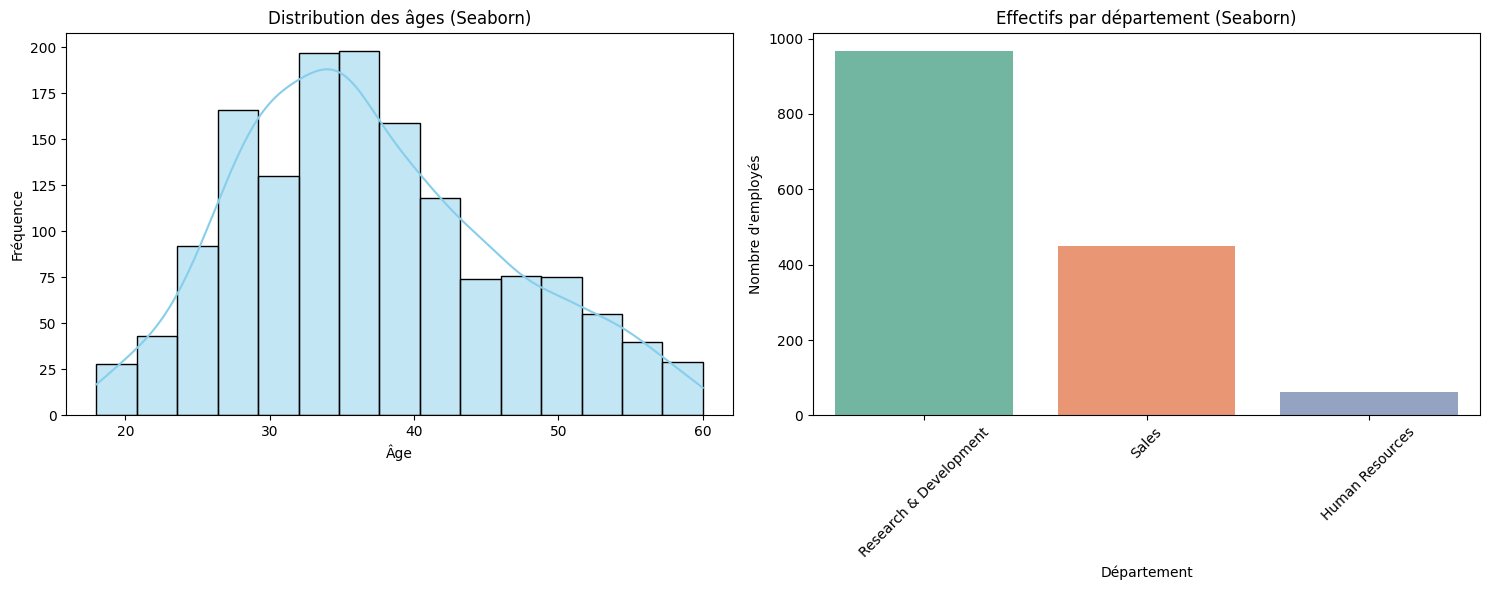

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(data=employees, x='Age', bins=15, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Distribution des âges (Seaborn)")
axes[0].set_xlabel("Âge")
axes[0].set_ylabel("Fréquence")

sns.countplot(data=employees, x='Department', ax=axes[1], palette='Set2')
axes[1].set_title("Effectifs par département (Seaborn)")
axes[1].set_xlabel("Département")
axes[1].set_ylabel("Nombre d'employés")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Mise en page (Subplots) : J'ai utilisé plt.subplots(1, 2) pour créer une structure de grille. Cela permet de comparer plusieurs indicateurs sur une seule figure.

Paramètres : L'argument ax=axes[i] permet de dire si l'on veut selectionner les lignes ou les colonnes. J'ai ajouté plt.tight_layout() pour que les titres et les noms d'axes ne se chevauchent pas.

### Question 10 - Choix d'un graphe.

Choisissez un type de graphe pour représenter graphiquement la distribution des âges des employés selon les départements, de manière à ce qu'on puisse comparer aussi les dispersions et les valeurs centrales de la distribution : créez le et affichez le.

/tmp/ipykernel_2851/2777831202.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=employees, x='Department', y='Age', palette='Set3')


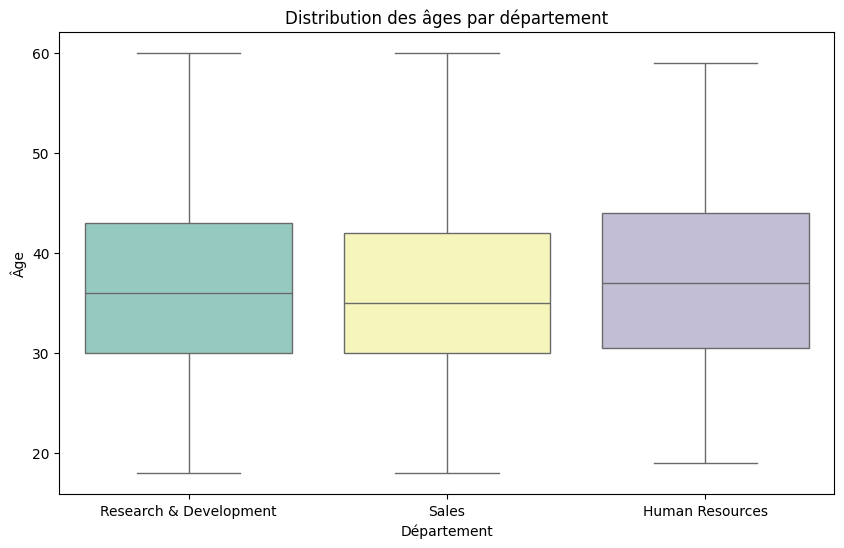

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=employees, x='Department', y='Age', palette='Set3')

plt.title("Distribution des âges par département")
plt.xlabel("Département")
plt.ylabel("Âge")
plt.show()

j'ai choisi le boxplot (boîte à moustaches).
La valeur centrale est représentée par la ligne de la médiane à l'intérieur de la boîte.

La dispersion est illustrée par l'étalement de la boîte (l'écart interquartile) et la longueur des moustaches.

les points isolés au-delà des moustaches permettent de repérer immédiatement les employés dont l'âge est très différent du reste de leur département.

### Question 11 - Approche graphique de la parité par département.

Comment représenter graphiquement le nombre de femmes et d'hommes au sein de chaque département sur le même graphe, afin qu'on puisse faire rapidement une estimation de quel département est le plus paritaire : créez ce graphe et affichez le.

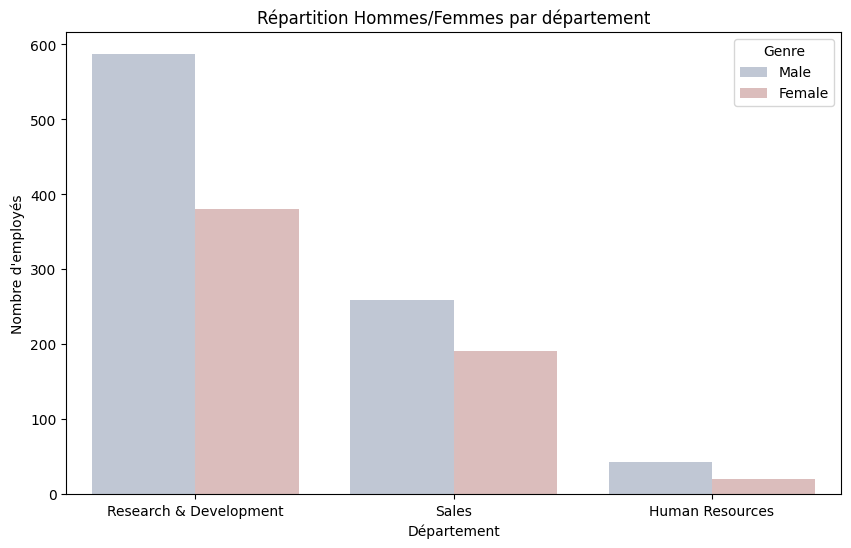

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.countplot(data=employees, x='Department', hue='Gender', palette='vlag')

plt.title("Répartition Hommes/Femmes par département")
plt.xlabel("Département")
plt.ylabel("Nombre d'employés")
plt.legend(title='Genre')
plt.show()

Pour la question 11, j'ai utilisé un graphique de type countplot avec l'argument hue='Gender' afin de mettre a coté les effectifs masculins et féminins par département, ce qui permet d'évaluer visuellement la parité.

## Partie 5 - Analyse avec plusieurs datasets

### Question 12 - Préparation du dataframe final.

Créez la table finale d'analyse puis affichez-en les premières lignes (pensez bien à justifier votre démarche).

Vérifiez les dimensions du dataset final.

In [20]:
df_final = employees.merge(employment, on='EmpID') \
                    .merge(performance, on='EmpID') \
                    .merge(compensation, on='EmpID')

print(df_final.head())
print(f"Dimensions du dataset final : {df_final.shape}")

   EmpID  Age  Gender  Education              Department  \
0  RM297   18    Male          3  Research & Development   
1  RM302   18  Female          3                   Sales   
2  RM458   18    Male          3                   Sales   
3  RM728   18    Male          2  Research & Development   
4  RM829   18    Male          1  Research & Development   

                 JobRole MaritalStatus AgeGroup  YearsAtCompany  \
0  Laboratory Technician        Single   Junior               0   
1   Sales Representative        Single   Junior               0   
2   Sales Representative        Single   Junior               0   
3     Research Scientist        Single   Junior               0   
4  Laboratory Technician        Single   Junior               0   

   YearsInCurrentRole  YearsSinceLastPromotion  YearsWithCurrManager  \
0                   0                        0                   0.0   
1                   0                        0                   0.0   
2                   

J'ai utilisé la méthode merge() pour regrouper les quatre dataframes en un seul tableau d'analyse unique en me basant sur la clé commune EmpID, ce qui permet de centraliser toutes les dimensions (démographie, emploi, performance et salaire) pour chaque individu tout en vérifiant avec .shape que le nombre de lignes correspond bien au total d'employés initial.

### Question 13 - Salaire par département.

Calculez le salaire moyen de chaque département, et créez une visualisation de la répartition des salaires dans chaque département à l'aide d'un graphe de votre choix que vous affichez ensuite.

Salaire moyen par département :
Department
Human Resources           6654.507937
Research & Development    6269.000000
Sales                     7060.090909
Name: MonthlyIncome, dtype: float64


/tmp/ipykernel_2851/430419259.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final, x='Department', y='MonthlyIncome', palette='muted')


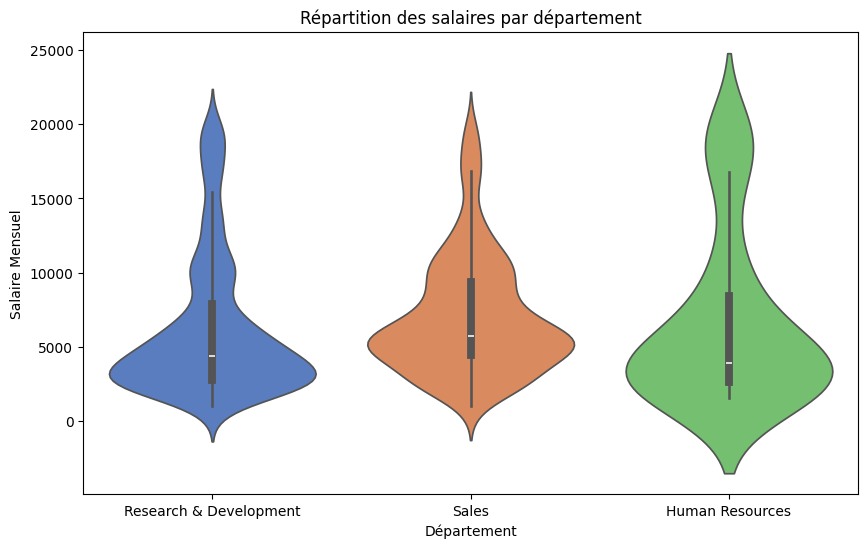

In [21]:
salaire_moyen_dept = df_final.groupby('Department')['MonthlyIncome'].mean()
print("Salaire moyen par département :")
print(salaire_moyen_dept)

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_final, x='Department', y='MonthlyIncome', palette='muted')
plt.title("Répartition des salaires par département")
plt.xlabel("Département")
plt.ylabel("Salaire Mensuel")
plt.show()

J'ai utilisé un violinplot car ce graphique combine les avantages d'une boîte à moustaches et d'une courbe de densité, ce qui permet de visualiser précisément la distribution, la concentration et les disparités de salaires au sein de chaque département tout en calculant la moyenne via un groupby pour obtenir une vue d'ensemble chiffrée.

### Question 14 - Relation entre âge et salaire.

Représentez graphiquement, avec un type de graphe adéquat, la relation entre l'âge des employés et leur salaire par département. Affichez le graphe et analysez le.

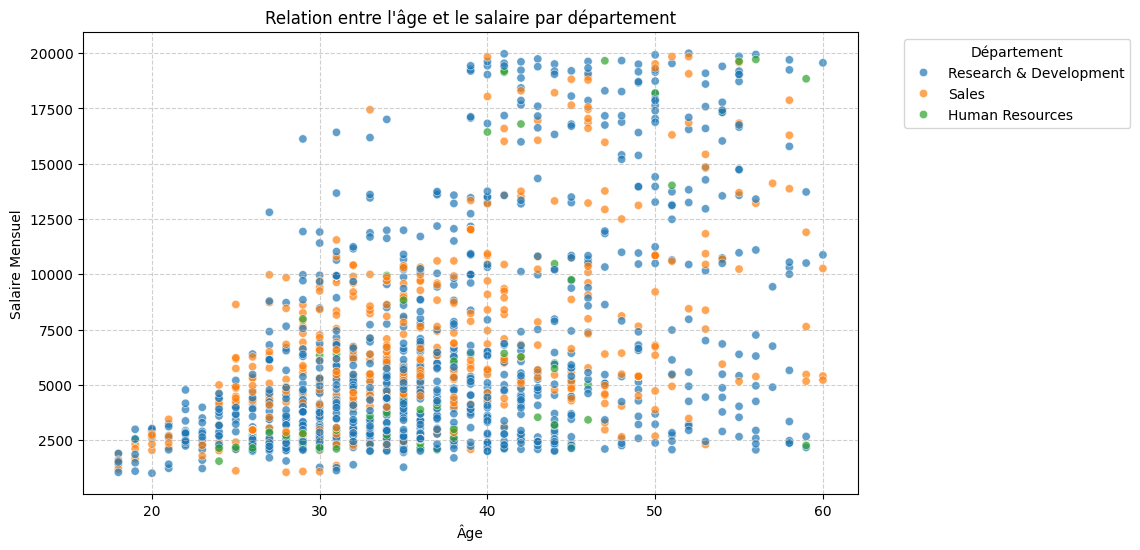

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x='Age', y='MonthlyIncome', hue='Department', alpha=0.7)

plt.title("Relation entre l'âge et le salaire par département")
plt.xlabel("Âge")
plt.ylabel("Salaire Mensuel")
plt.legend(title='Département', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

J'ai réalisé un nuage de points (scatterplot) coloré par département.

### Question 15 - Parité salariale par département.

Que peut-on dire de la parité salariale par département ? Trouvez un graphe qui permet de visualiser la répartition des salaires par département et d'analyser cette parité. Affichez le graphe et analysez le.

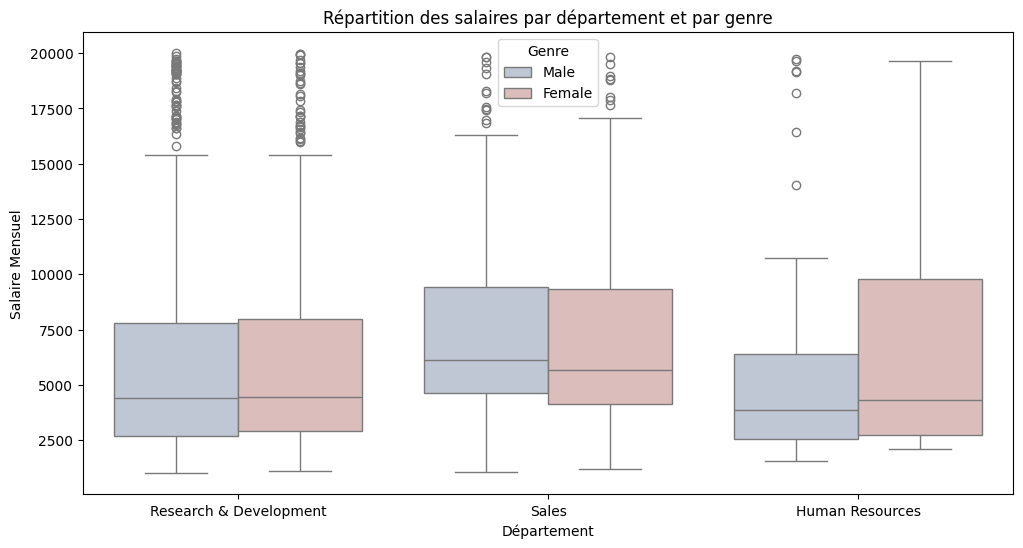

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_final, x='Department', y='MonthlyIncome', hue='Gender', palette='vlag')

plt.title("Répartition des salaires par département et par genre")
plt.xlabel("Département")
plt.ylabel("Salaire Mensuel")
plt.legend(title='Genre')
plt.show()

J'ai choisi un boxplot avec l'argument hue='Gender'
Nous pouvons observé que le departement human ressources a une ingéalité homme femmes au niveau des salaires.



### Question 16 - Analyses des différents postes présents dans l'entreprise.

Combien y a-t-il de postes différents dans l'entreprise ? Quels sont les postes les mieux payés ? Analysez graphiquement.

Il y a 9 postes différents dans l'entreprise.

Salaires moyens par poste :
JobRole
Manager                      17181.676471
Research Director            16033.550000
Healthcare Representative     7781.732877
Manufacturing Director        7422.657143
Sales Executive               7227.601078
Human Resources               4235.750000
Research Scientist            3266.602606
Laboratory Technician         3263.155709
Sales Representative          2678.040816
Name: MonthlyIncome, dtype: float64


/tmp/ipykernel_2851/32208288.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=salaire_par_poste.values, y=salaire_par_poste.index, palette='viridis')


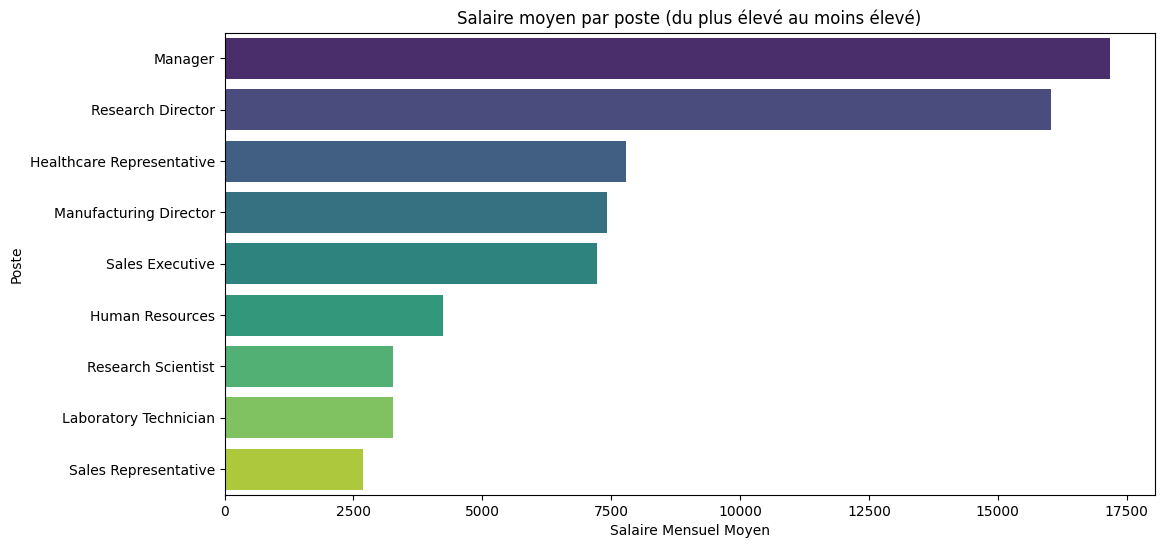

In [24]:
nb_postes = df_final['JobRole'].nunique()
print(f"Il y a {nb_postes} postes différents dans l'entreprise.")

salaire_par_poste = df_final.groupby('JobRole')['MonthlyIncome'].mean().sort_values(ascending=False)
print("\nSalaires moyens par poste :")
print(salaire_par_poste)

plt.figure(figsize=(12, 6))
sns.barplot(x=salaire_par_poste.values, y=salaire_par_poste.index, palette='viridis')
plt.title("Salaire moyen par poste (du plus élevé au moins élevé)")
plt.xlabel("Salaire Mensuel Moyen")
plt.ylabel("Poste")
plt.show()

J'ai utilisé la méthode nunique() pour identifier le nombre précis de métiers et un groupby trié par ordre décroissant pour isoler les postes les mieux rémunérés, comme les "Manager" ou "Research Director". Pour l'analyse graphique, j'ai choisi un barre plot horizontal car il offre une lecture immédiate du classement des salaires et permet de lire les noms des postes sans qu'ils ne se chevauchent sur l'axe des ordonnées.

### Question 17 - Analyse des corrélations entre variables.

0n souhaite savoir s'il y a une corrélation entre :

- l'âge des employés,
- leur salaire mensuel,
- leur ancienneté en années dans l'entreprise,
- leur note de performance,
- leur satisfaction au travail.

Trouvez une façon de répondre graphiquement à la question, et affichez le graphe correspondant.

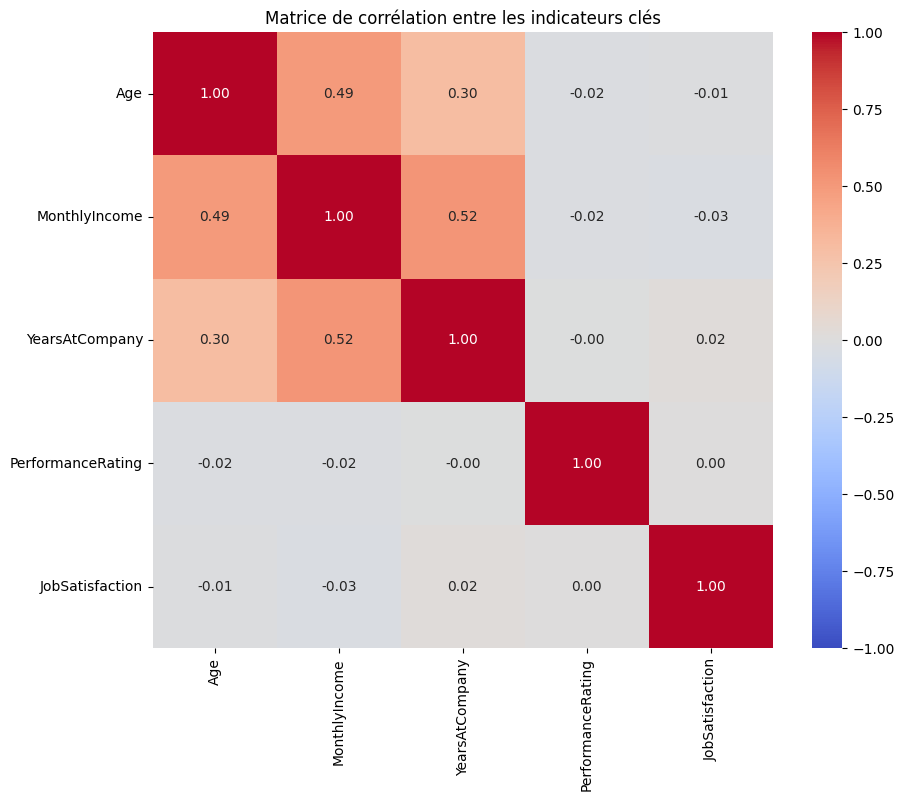

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_etudiees = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'PerformanceRating', 'JobSatisfaction']
df_corr = df_final[cols_etudiees]

matrice_corr = df_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matrice_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title("Matrice de corrélation entre les indicateurs clés")
plt.show()

J'ai utilisé une Heatmap (carte de chaleur) car c'est l'outil le plus efficace pour visualiser simultanément les relations entre plusieurs variables numériques. Ce graphique permet de lire instantanément le coefficient de corrélation de Pearson grâce à un code couleur : une valeur proche de 1 (rouge) indique une forte corrélation positive, comme c'est souvent le cas entre l'âge et le salaire, tandis qu'une valeur proche de 0 montre une absence de lien linéaire entre deux variables.

### Question 18 - Relation entre satisfaction au travail et salaire.

Y a-t-il une relation entre la satisfaction au travail et le salaire des employés de l'entreprise ?

/tmp/ipykernel_2851/661658593.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='JobSatisfaction', y='MonthlyIncome', palette='coolwarm')


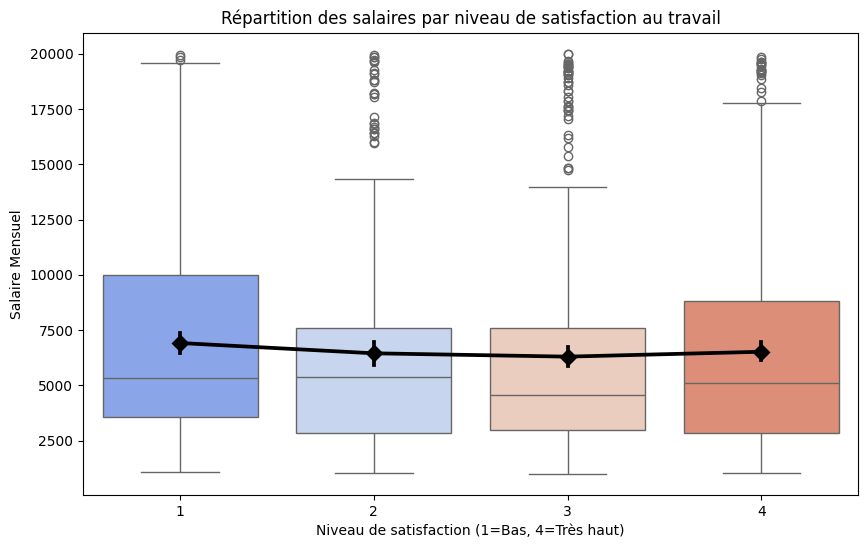

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_final, x='JobSatisfaction', y='MonthlyIncome', palette='coolwarm')

sns.pointplot(data=df_final, x='JobSatisfaction', y='MonthlyIncome', color='black', markers='D')

plt.title("Répartition des salaires par niveau de satisfaction au travail")
plt.xlabel("Niveau de satisfaction (1=Bas, 4=Très haut)")
plt.ylabel("Salaire Mensuel")
plt.show()

J'ai choisi d'utiliser un boxplot complété par un pointplot (pour afficher la moyenne) car la satisfaction est une donnée ordinale (notée de 1 à 4) ; cela permet de voir si les salaires médians et moyens augmentent avec le bien-être au travail. L'analyse visuelle du graphique permet de conclure s'il existe une corrélation réelle : si les boîtes sont sensiblement au même niveau, cela signifie que, dans cette entreprise, le salaire n'est pas le levier principal de la satisfaction déclarée par les employés.

Le niveau de satisafaction est équilibré. Je ne pense donc pas que cela est un lien direct.

### Question 19 - Équilibre entre la vie professionnelle et vie personnelle.

Quel département semble garantir le meilleur équilibre entre la vie professionnelle et la vie personnelle de ses employés ?

Score moyen d'équilibre vie pro/vie perso par département :
Department
Human Resources           2.920635
Sales                     2.778656
Research & Development    2.734539
Name: WorkLifeBalance, dtype: float64


/tmp/ipykernel_2851/437209715.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=wlb_stats.index, y=wlb_stats.values, palette='viridis')


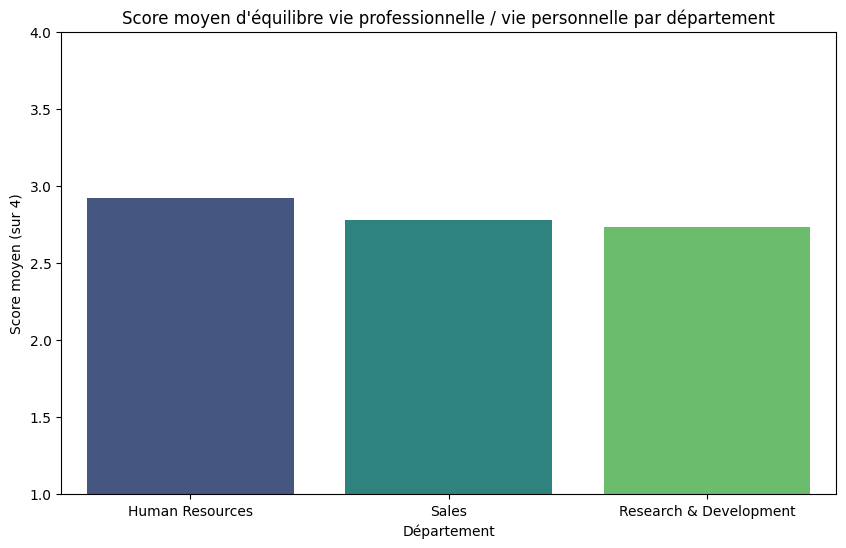

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

wlb_stats = df_final.groupby('Department')['WorkLifeBalance'].mean().sort_values(ascending=False)
print("Score moyen d'équilibre vie pro/vie perso par département :")
print(wlb_stats)

plt.figure(figsize=(10, 6))
sns.barplot(x=wlb_stats.index, y=wlb_stats.values, palette='viridis')

plt.title("Score moyen d'équilibre vie professionnelle / vie personnelle par département")
plt.xlabel("Département")
plt.ylabel("Score moyen (sur 4)")
plt.ylim(1, 4)
plt.show()

Le departement Human Resources semble garantir le meilleur équilibre.

J'ai utilisé un groupby sur la colonne Department pour calculer la moyenne de l'indicateur WorkLifeBalance.

### Question 20 - Étude du taux d'attrition.

Représentez graphiquement le taux d'attrition (ce qui signifie le turnover) par département.

/tmp/ipykernel_2851/1028005651.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attrition_rate.index, y=attrition_rate.values, palette='Reds_r')


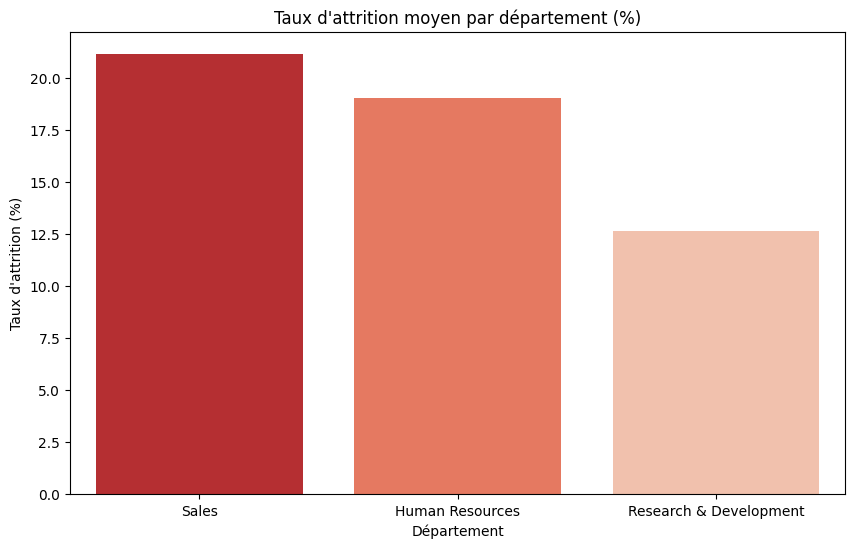

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

df_final['Attrition_Numeric'] = df_final['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

attrition_rate = df_final.groupby('Department')['Attrition_Numeric'].mean() * 100
attrition_rate = attrition_rate.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=attrition_rate.index, y=attrition_rate.values, palette='Reds_r')

plt.title("Taux d'attrition moyen par département (%)")
plt.xlabel("Département")
plt.ylabel("Taux d'attrition (%)")
plt.show()

J'ai d'abord converti la variable textuelle Attrition en données numériques pour pouvoir calculer une moyenne, ce qui représente mathématiquement le taux de départ pour chaque groupe. J'ai ensuite utilisé un barplot pour comparer ces taux entre les départements.